In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#Load dataset
df = pd.read_csv("data/sales_data.csv")

print("="*50)
print("First 5 Rows")
print("="*50)
print(df.head())

First 5 Rows
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680


In [6]:
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 5.6 KB
None


In [7]:
#Checking missing values

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [22]:
# DATA CLEANING

# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [9]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
# Create Month column
df['Month'] = df['Date'].dt.strftime('%b')

In [11]:
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
                      Date    Quantity         Price    Total_Sales
count                  100  100.000000    100.000000     100.000000
mean   2024-02-19 12:00:00    4.780000  25808.510000  123650.480000
min    2024-01-01 00:00:00    1.000000   1308.000000    6540.000000
25%    2024-01-25 18:00:00    2.750000  14965.250000   39517.500000
50%    2024-02-19 12:00:00    5.000000  24192.000000   97955.500000
75%    2024-03-15 06:00:00    7.000000  38682.250000  175792.500000
max    2024-04-09 00:00:00    9.000000  49930.000000  373932.000000
std                    NaN    2.588163  13917.630242  100161.085275


In [23]:
# KPI ANALYSIS

total_sales = df['Total_Sales'].sum()
total_orders = len(df)
total_quantity = df['Quantity'].sum()
average_sales = df['Total_Sales'].mean()

#Best Selling Product
best_product = (
    df.groupby("Product")["Quantity"]
    .sum()
    .idxmax()
)


print("\n========== KPIs ==========")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Average Order Value: ₹{average_sales:,.2f}")
print(f"Best Selling Product: {best_product}")



========== KPIs ==========
Total Sales: ₹12,365,048.00
Total Orders: 100
Total Quantity Sold: 478
Average Order Value: ₹123,650.48
Best Selling Product: Laptop


In [13]:
# PRODUCT ANALYSIS

product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)


print("\nSales by Product")
print(product_sales)


Sales by Product
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64


In [14]:
# REGION ANALYSIS

region_sales = df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)

print("\nSales by Region")
print(region_sales)


Sales by Region
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64


In [15]:
# MONTHLY SALES

monthly_sales = df.groupby('Month')['Total_Sales'].sum()

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_sales = monthly_sales.reindex(month_order)

print("\nMonthly Sales")
print(monthly_sales)



Monthly Sales
Month
Jan    4120524.0
Feb    2656050.0
Mar    4485006.0
Apr    1103468.0
May          NaN
Jun          NaN
Jul          NaN
Aug          NaN
Sep          NaN
Oct          NaN
Nov          NaN
Dec          NaN
Name: Total_Sales, dtype: float64


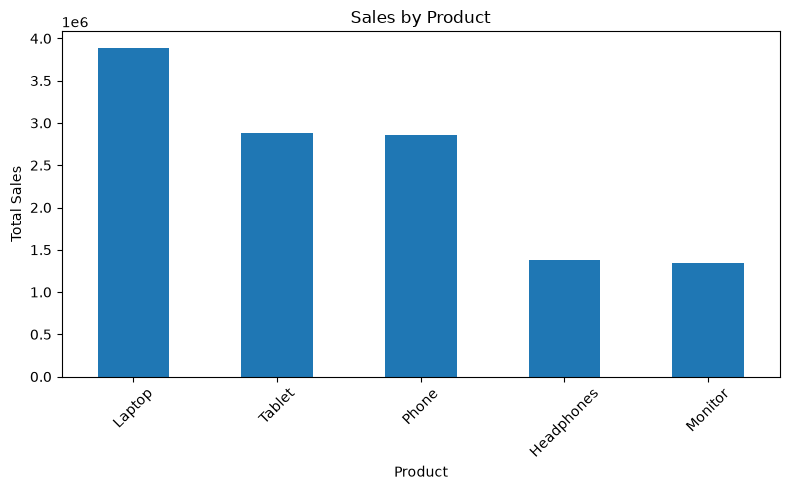

In [16]:
# CHART 1
# Product Sales

plt.figure(figsize=(8,5))
product_sales.plot(kind='bar')

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("product_sales.png")
plt.show()

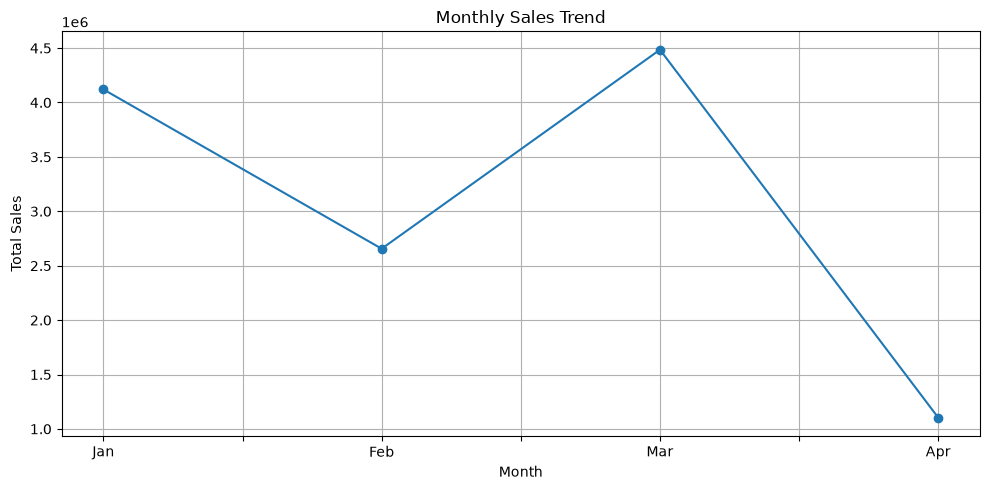

In [17]:
# CHART 2
# Monthly Sales Trend

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()


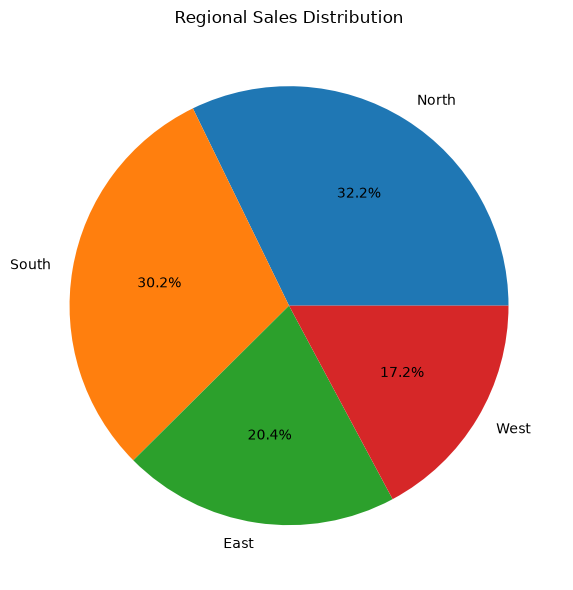

In [18]:
# CHART 3
# Region Sales

plt.figure(figsize=(6,6))
region_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Regional Sales Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("region_sales.png")
plt.show()


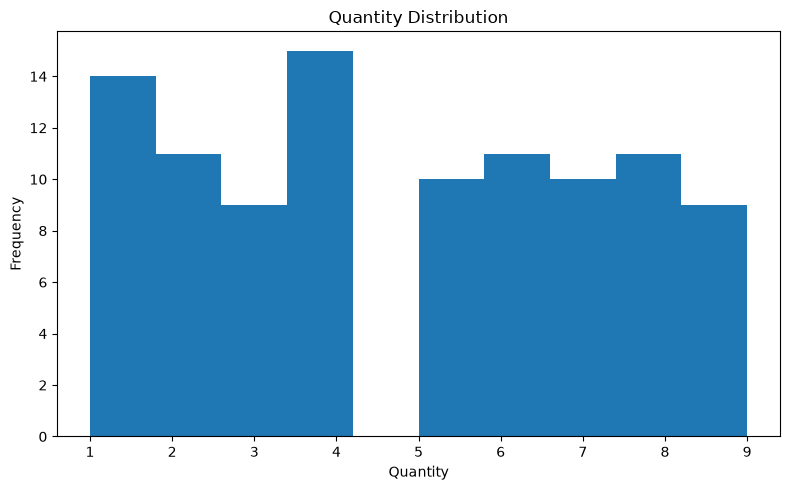

In [19]:
# CHART 4
# Quantity Distribution

plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=10)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("quantity_distribution.png")
plt.show()


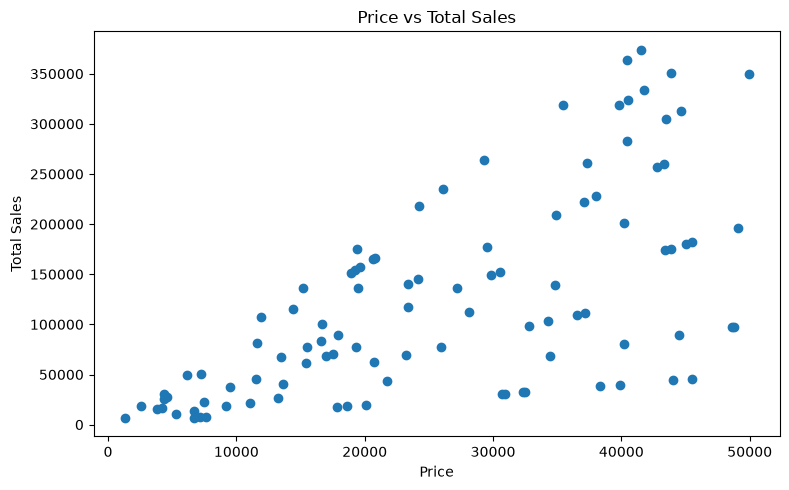

In [20]:
# CHART 5
# Price vs Total Sales

plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Total_Sales'])

plt.title("Price vs Total Sales")
plt.xlabel("Price")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("price_vs_sales.png")
plt.show()

In [21]:
# BUSINESS INSIGHTS

print("\n-------- BUSINESS INSIGHTS -------- \n")

print(f"1. Total Revenue Generated: ₹{total_sales:,.2f}")

print(f"2. Highest Selling Product: {product_sales.idxmax()}")

print(f"3. Highest Revenue Region: {region_sales.idxmax()}")

print(f"4. Total Quantity Sold: {total_quantity}")

print(f"5. Average Order Value: ₹{average_sales:,.2f}")

print("\nAnalysis Completed Successfully!")


-------- BUSINESS INSIGHTS -------- 

1. Total Revenue Generated: ₹12,365,048.00
2. Highest Selling Product: Laptop
3. Highest Revenue Region: North
4. Total Quantity Sold: 478
5. Average Order Value: ₹123,650.48

Analysis Completed Successfully!
